In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import string
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from phe import paillier
from sklearn.linear_model import LinearRegression

In [71]:
spamFolder1 = 'C:/Users/asus/Desktop/SpamData/enron1 (2)/enron1/spam'
spamFolder2 = 'C:/Users/asus/Desktop/SpamData/enron2 (1)/enron2/spam'

hamFolder1 = 'C:/Users/asus/Desktop/SpamData/enron1 (2)/enron1/ham'
hamFolder2 = 'C:/Users/asus/Desktop/SpamData/enron2 (1)/enron2/ham'

In [72]:
def custom_tokenizer(text):
    tokens = nltk.word_tokenize(text)

    tokens_lower = []
    for token in tokens:
        tokens_lower.append(token.lower())
    
    stop_words = set(stopwords.words('english'))
    punctuation = set(string.punctuation)

    filtered_elements = []
    for element in tokens_lower:
        if element not in stop_words and element not in punctuation and not element.isdigit():
            filtered_elements.append(element)
    return filtered_elements

In [73]:
def vectorizeData(spam_path, ham_path):
    spam_files = os.listdir(spam_path)
    ham_files = os.listdir(ham_path)
    
    vocabulary = []
    y = []
    for filenames in spam_files:
        sentence = ""
        cur_file = open(spam_path + "/" + filenames, errors='ignore')
        sentence = cur_file.read()
        vocabulary.append(sentence)
        y.append(1)
    
    for filenames in ham_files:
        sentence = ""
        cur_file = open(ham_path + "/" + filenames, errors='ignore')
        sentence = cur_file.read()
        vocabulary.append(sentence)
        y.append(0)

    vectorizer = TfidfVectorizer(tokenizer=custom_tokenizer, min_df=0.0001)
    X = vectorizer.fit_transform(vocabulary)
    feature_names = vectorizer.get_feature_names_out()
    return X, y, feature_names


X, y, feature_names = vectorizeData(spamFolder2, hamFolder2)
tfidf = pd.DataFrame(X.toarray(), columns=feature_names)
print(tfidf)
print(y)
    

C:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


                                              ...  þtiene    –    ‘  \
0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
1     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
2     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
3     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
4     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...     ...  ...  ...   
5852  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
5853  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
5854  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
5855  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
5856  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   

             ’        “      

In [74]:
X, y = shuffle(X, y, random_state=0)
tfidf2 = pd.DataFrame(X.toarray(), columns=feature_names)
print(tfidf2)
print(y)

                                              ...  þtiene    –    ‘  \
0     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
1     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
2     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
3     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
4     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...     ...  ...  ...   
5852  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
5853  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
5854  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
5855  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   
5856  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...     0.0  0.0  0.0   

        ’    “    ”    •    …

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [76]:
classifier = svm.LinearSVC()

In [77]:
classifier.fit(X_train, y_train)

C:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC()

In [78]:
y_pred = classifier.predict(X_test)

In [79]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.9948805460750854


In [80]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[871   1]
 [  5 295]]


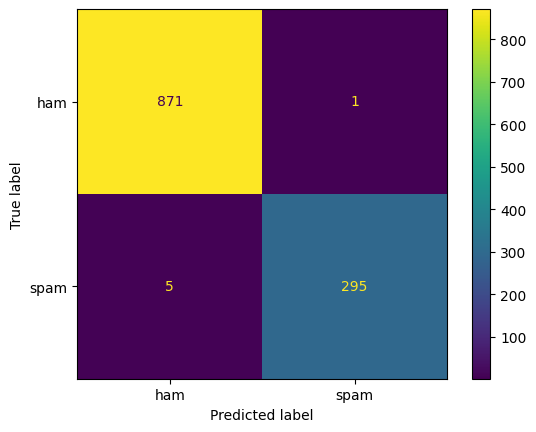

In [81]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ['ham', 'spam'])

cm_display.plot()
plt.show()

In [82]:
precision = precision_score(y_test,y_pred)
print(precision)

0.9966216216216216
